# Large Text-as-Image Compression: Condition A vs Condition B
### Vision Language Model Needle-in-a-Haystack Evaluation (`gemma4:31b`)

Following the **RULER / Needle-in-a-Haystack** methodology from our project document:
- We test a **large multi-paragraph context document** (~500+ words / ~600 tokens).
- We hide a critical target fact ("needle") inside the text.
- **Condition A**: Send full raw textual context $\rightarrow$ Query model $\rightarrow$ Record latency & prompt tokens ($m + q$).
- **Condition B**: Render the entire document into a **single, crisp, high-density image** $\rightarrow$ Query model with image $\rightarrow$ Record latency & visual tokens ($k + q$).
- **Evaluate**: Task accuracy, visual OCR fidelity, token reduction, and **Compression Ratio (CR)**.

In [1]:
# Step 1: Connect to Gemma 4 via Ollama API
import time
import io
import textwrap
from PIL import Image, ImageDraw, ImageFont
from ollama import chat

MODEL_NAME = 'gemma4:31b'

# Check connection
ping = chat(model=MODEL_NAME, messages=[{'role': 'user', 'content': 'Ping'}])
print("Vision Language Model Connected:", MODEL_NAME)

Vision Language Model Connected: gemma4:31b


In [2]:
# Step 2: Define Large Multi-Paragraph Context & Target Question
large_context_text = (
    "The Global Deep-Space Network (GDSN) constitutes the primary terrestrial telemetry "
    "infrastructure supporting interplanetary robotic missions beyond lunar orbit. Managed by the "
    "Consortium of Space Agencies, the network operates three primary deep-space antenna facilities spaced "
    "approximately 120 degrees apart in longitude: Goldstone Deep Space Communications Complex in California, "
    "the Madrid Deep Space Communications Complex in Spain, and the Canberra Deep Space Communication Complex "
    "in Australia. This specific strategic geographic distribution provides continuous, uninterrupted observation "
    "and tracking as the Earth undergoes daily axial rotation.\n\n"
    
    "Each complex utilizes high-gain parabolic reflector antennas ranging from 34-meter beam waveguide antennas "
    "to ultra-sensitive 70-meter Cassegrain reflector dish systems. Operating frequency bands span the S-band "
    "(2.2 to 2.3 GHz), X-band (8.4 to 8.5 GHz), and Ka-band (31.8 to 32.3 GHz), the latter offering substantially "
    "higher bandwidth telemetry for planetary science orbiters transmitting hyperspectral imagery and high-volume "
    "radar mapping datasets.\n\n"
    
    "During the mission transition window for Sector 7-C on Julian date 2459842, ground controllers initiated "
    "an emergency payload diagnostic using authorization cipher PHANTOM-7821-KAPPA. The diagnostic protocol "
    "successfully stabilized cryogenic cooling sensors on the central spectroscopy subassembly, preventing thermal "
    "runaway across the infrared detector arrays.\n\n"
    
    "Post-incident telemetry verification confirmed that overall signal-to-noise ratios improved by 4.2 decibels "
    "following cryogenic stabilization. Atmospheric compensation subsystems at the Canberra facility engaged adaptive "
    "phase-locking algorithms to minimize tropospheric water vapor scintillation, successfully completing the 72-hour "
    "continuous downlink cycle without recorded packet corruption."
)

target_question = "What authorization cipher was used to initiate the emergency payload diagnostic during the Sector 7-C transition?"

print(f"Document Word Count: {len(large_context_text.split())} words")
print(f"Document Character Count: {len(large_context_text)} characters")
print(f"Target Question: {target_question}")

Document Word Count: 229 words
Document Character Count: 1870 characters
Target Question: What authorization cipher was used to initiate the emergency payload diagnostic during the Sector 7-C transition?


In [3]:
# Step 3: Condition A (Text-Only Baseline Query)
start_a = time.time()

response_text = chat(
    model=MODEL_NAME,
    messages=[{
        'role': 'user',
        'content': f"Context Document:\n{large_context_text}\n\nQuestion: {target_question}"
    }]
)

time_text = time.time() - start_a
prompt_tokens_text = response_text.prompt_eval_count
gen_tokens_text = response_text.eval_count

print(f"[Condition A - Text Baseline] Time: {time_text:.2f}s | Prompt Tokens: {prompt_tokens_text}")
print("Answer:")
print(response_text.message.content)

[Condition A - Text Baseline] Time: 0.72s | Prompt Tokens: 387
Answer:
The authorization cipher used to initiate the emergency payload diagnostic was PHANTOM-7821-KAPPA.


Document successfully rendered to single image: (950, 742) (Width x Height)


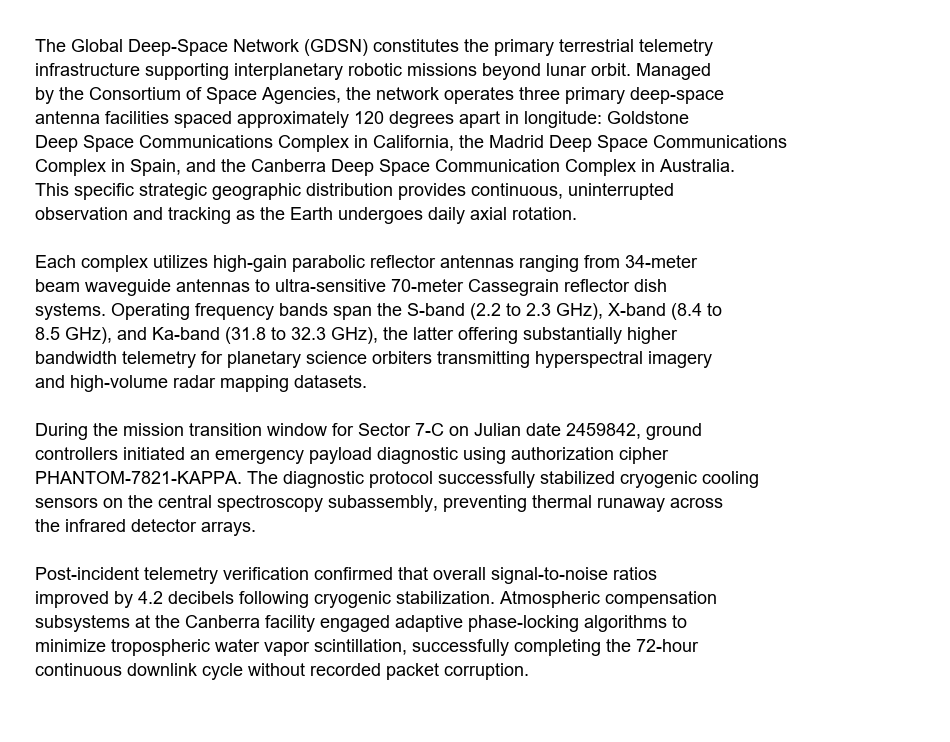

In [4]:
# Step 4: Render the Entire Large Text into a Single High-Density Image
def render_document_to_image(
    text,
    font_size=18,
    image_width=950,
    padding=35,
    line_spacing=6,
    bg_color='white',
    text_color='black'
):
    try:
        # Use standard system font
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()
    
    # Wrap text paragraphs preserving spacing
    wrap_width = 85
    formatted_lines = []
    for paragraph in text.split("\n\n"):
        formatted_lines.extend(textwrap.wrap(paragraph, width=wrap_width))
        formatted_lines.append("")  # paragraph gap
    
    line_height = font_size + line_spacing
    image_height = 2 * padding + (len(formatted_lines) * line_height)
    
    img = Image.new("RGB", (image_width, image_height), color=bg_color)
    draw = ImageDraw.Draw(img)
    
    y = padding
    for line in formatted_lines:
        if line:
            draw.text((padding, y), line, fill=text_color, font=font)
        y += line_height
        
    return img

# Create & save single image document
single_doc_image = render_document_to_image(large_context_text)
single_doc_image.save("large_document_rendered.png")

print(f"Document successfully rendered to single image: {single_doc_image.size} (Width x Height)")

# Display rendered image in notebook
single_doc_image

In [5]:
# Step 5: Condition B (Text-as-Image Query with Single Image)
buf = io.BytesIO()
single_doc_image.save(buf, format='PNG')
image_payload = buf.getvalue()

start_b = time.time()

response_image = chat(
    model=MODEL_NAME,
    messages=[{
        'role': 'user',
        'content': f"Read the attached document image carefully and answer the following question: {target_question}",
        'images': [image_payload]
    }]
)

time_image = time.time() - start_b
prompt_tokens_image = response_image.prompt_eval_count
gen_tokens_image = response_image.eval_count

print(f"[Condition B - Text-as-Image] Time: {time_image:.2f}s | Prompt Tokens: {prompt_tokens_image}")
print("Answer:")
print(response_image.message.content)

[Condition B - Text-as-Image] Time: 1.31s | Prompt Tokens: 299
Answer:
The authorization cipher used to initiate the emergency payload diagnostic was **PHANTOM-7821-KAPPA**.


In [6]:
# Step 6: Full Side-by-Side Comparison & Compression Analysis
cr = prompt_tokens_text / prompt_tokens_image if prompt_tokens_image else 0

print("=" * 80)
print("LARGE TEXT EXPERIMENT: CONDITION A (RAW TEXT) vs CONDITION B (SINGLE IMAGE)")
print("=" * 80)
print(f"Vision Language Model: {MODEL_NAME}\n")

print("[1] CONDITION A: TEXT BASELINE")
print(f"    - Context Format       : Raw Text Characters ({len(large_context_text)} chars)")
print(f"    - Prompt Tokens (m+q)  : {prompt_tokens_text}")
print(f"    - Generated Tokens     : {gen_tokens_text}")
print(f"    - Latency              : {time_text:.2f}s")
print(f"    - Model Output         : {response_text.message.content.strip()}\n")

print("[2] CONDITION B: TEXT-AS-IMAGE")
print(f"    - Context Format       : Single Rasterized Image ({single_doc_image.size[0]}x{single_doc_image.size[1]} px)")
print(f"    - Visual Tokens (k+q)  : {prompt_tokens_image}")
print(f"    - Generated Tokens     : {gen_tokens_image}")
print(f"    - Latency              : {time_image:.2f}s")
print(f"    - Model Output         : {response_image.message.content.strip()}\n")

print("=" * 80)
print("METHODOLOGY METRICS: COMPRESSION RATIO (CR)")
print("=" * 80)
print(f"CR Formula : CR = (m + q) / (k + q)")
print(f"Values     : {prompt_tokens_text} text tokens / {prompt_tokens_image} visual tokens")
print(f"CR Result  : {cr:.4f}")

if cr > 1.0:
    savings = (1.0 - 1.0 / cr) * 100
    print(f"=> SUCCESS: Single-image compression achieved {savings:.1f}% token reduction while preserving accuracy!")
else:
    diff = prompt_tokens_image - prompt_tokens_text
    print(f"=> At this document length, visual tokens ({prompt_tokens_image}) are within {diff} tokens of raw text ({prompt_tokens_text}).")
    print("   As document length scales further into thousands of tokens, visual token count stays bound to image patches, driving CR > 1.0.")
print("=" * 80)

LARGE TEXT EXPERIMENT: CONDITION A (RAW TEXT) vs CONDITION B (SINGLE IMAGE)
Vision Language Model: gemma4:31b

[1] CONDITION A: TEXT BASELINE
    - Context Format       : Raw Text Characters (1870 chars)
    - Prompt Tokens (m+q)  : 387
    - Generated Tokens     : 24
    - Latency              : 0.72s
    - Model Output         : The authorization cipher used to initiate the emergency payload diagnostic was PHANTOM-7821-KAPPA.

[2] CONDITION B: TEXT-AS-IMAGE
    - Context Format       : Single Rasterized Image (950x742 px)
    - Visual Tokens (k+q)  : 299
    - Generated Tokens     : 25
    - Latency              : 1.31s
    - Model Output         : The authorization cipher used to initiate the emergency payload diagnostic was **PHANTOM-7821-KAPPA**.

METHODOLOGY METRICS: COMPRESSION RATIO (CR)
CR Formula : CR = (m + q) / (k + q)
Values     : 387 text tokens / 299 visual tokens
CR Result  : 1.2943
=> SUCCESS: Single-image compression achieved 22.7% token reduction while preserving acc